In [1]:
from datascience import *
#path_data = '../data/'
path_data = 'data/'
import matplotlib
matplotlib.use('Agg')
%matplotlib inline
import matplotlib.pyplot as plots
plots.style.use('fivethirtyeight')
import numpy as np

# 모집단에서 표본추출

대수의 법칙은 무작위 표본이 대규모 모집단의 개체들로부터 추출될 때도 성립합니다.

예를 들어, 비행 지연 시간의 모집단을 연구할 것입니다. 테이블 `united`는 2015년 여름 샌프란시스코에서 출발하는 United Airlines 국내선 항공편에 대한 데이터를 포함합니다. 데이터는 미국 교통부의 [교통 통계국(Bureau of Transportation Statistics)](http://www.transtats.bts.gov/Fields.asp?Table_ID=293)에서 공개적으로 제공됩니다.

13,825개의 행이 있으며, 각각 항공편에 해당합니다. 열은 비행 날짜, 항공편 번호, 목적지 공항 코드, 출발 지연 시간(분)입니다. 일부 지연 시간은 음수입니다: 해당 항공편은 일찍 출발했습니다.

In [3]:
united = Table.read_table(path_data + 'united_summer2015.csv')
united

Date,Flight Number,Destination,Delay
6/1/15,73,HNL,257
6/1/15,217,EWR,28
6/1/15,237,STL,-3
6/1/15,250,SAN,0
6/1/15,267,PHL,64
6/1/15,273,SEA,-6
6/1/15,278,SEA,-8
6/1/15,292,EWR,12
6/1/15,300,HNL,20
6/1/15,317,IND,-10


한 항공편은 16분 일찍 출발했고, 한 항공편은 580분 늦게 출발했습니다. 다른 지연 시간은 거의 모두 -10분에서 200분 사이였으며, 아래 히스토그램에서 볼 수 있습니다.

In [4]:
united.column('Delay').min()

-16

In [4]:
united.column('Delay').max()

-16

In [5]:
np.arange(-20, 301, 10)

580

In [ ]:
#delay_bins = np.append(np.arange(-20, 301, 10), 600)
delay_bins = np.arange(-20, 601, 10)
united.hist('Delay', bins = delay_bins, unit = 'minute')

array([-20, -10,   0,  10,  20,  30,  40,  50,  60,  70,  80,  90, 100,
       110, 120, 130, 140, 150, 160, 170, 180, 190, 200, 210, 220, 230,
       240, 250, 260, 270, 280, 290, 300])

이 절의 목적을 위해 데이터의 대부분을 확대하고 200분 이상 지연된 0.8%의 항공편을 무시하는 것으로 충분합니다. 이 제한은 시각적 편의를 위한 것일 뿐이며 테이블은 여전히 모든 데이터를 유지합니다.

In [7]:
united.where('Delay', are.above(200)).num_rows/united.num_rows

0.008390596745027125

In [7]:
delay_bins = np.arange(-20, 201, 10)
united.hist('Delay', bins = delay_bins, unit = 'minute')

0.008390596745027125

[0, 10) 막대의 높이는 분당 3% 바로 아래이며, 이는 항공편의 약 30%가 0분에서 10분 사이의 지연이 있었음을 의미합니다. 이것은 행을 세어 확인됩니다:

In [9]:
united.where('Delay', are.between(0, 10)).num_rows/united.num_rows

0.2935985533453888

## 표본의 경험적 분포

이제 13,825편의 항공편을 모집단으로 생각하고 복원추출로 무작위 표본을 추출해봅시다. 코드를 함수로 패키징하는 것이 도움이 됩니다. 함수 `empirical_hist_delay`는 표본 크기를 인수로 받아 결과의 경험적 히스토그램을 그립니다.

In [10]:
def empirical_hist_delay(n):
    united.sample(n).hist('Delay', bins = delay_bins, unit = 'minute')

주사위에서 본 것처럼 표본 크기가 증가함에 따라 표본의 경험적 히스토그램은 모집단의 히스토그램을 더 밀접하게 닮습니다. 이 히스토그램들을 위의 모집단 히스토그램과 비교해보세요.

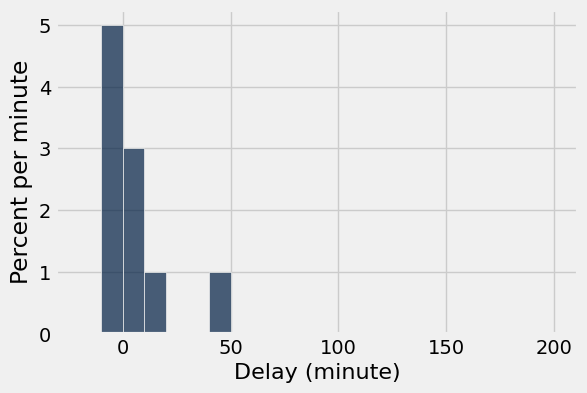

In [26]:
empirical_hist_delay(10)

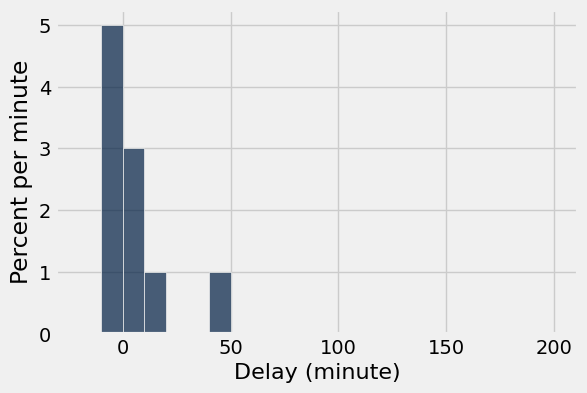

In [26]:
empirical_hist_delay(100)

가장 일관되게 눈에 띄는 불일치는 모집단에서 드문 값들 사이에 있습니다. 우리 예제에서 이러한 값은 분포의 오른쪽 꼬리에 있습니다. 그러나 표본 크기가 증가함에 따라 이러한 값들도 대략 올바른 비율로 표본에 나타나기 시작합니다.

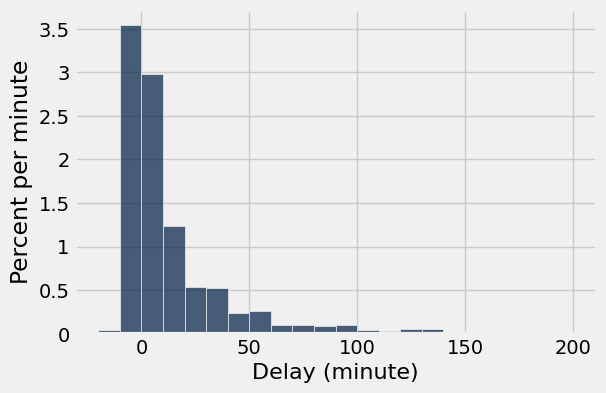

In [39]:
empirical_hist_delay(1000)

## 표본의 경험적 히스토그램의 수렴
이 절에서 관찰한 내용은 다음과 같이 요약할 수 있습니다:

대규모 무작위 표본의 경우, 표본의 경험적 히스토그램은 높은 확률로 모집단의 히스토그램과 닮습니다.

이것은 통계적 추론에서 대규모 무작위 표본의 사용을 정당화합니다. 아이디어는 대규모 무작위 표본이 추출된 모집단과 닮을 가능성이 높기 때문에 표본의 값으로부터 계산된 양이 모집단의 해당 양에 가까울 가능성이 높다는 것입니다.